In [1]:
import pandas as pd
import numpy as np
import os

# ==========================================
# PROMPT 2: BİRDEN FAZLA HİSSENİN BİRLEŞTİRİLMESİ
# ==========================================

# Dosya adlarını ve veri setinde görünecek kısa isimlerini tanımlıyoruz
hisseler = {
    'AKBNK': 'akbnk-akbank.csv',
    'ASELS': 'asels-aselsan.csv', 
    'BIMAS': 'bimas-bim-magazalar.csv',  
    'BRSAN': 'brsan-borusan-mannesmann.csv',
    'EREGL': 'eregl-eregli-demir-celik.csv', 
    'THYAO': 'thyao-turk-hava-yollari.csv'     
}

# Tüm hisselerin temizlenmiş verilerini toplamak için boş bir liste oluşturuyoruz
all_data = []

print("--- Hisseler Yükleniyor ve Temizleniyor ---")

for kısa_ad, dosya_adı in hisseler.items():
    # Dosyanın varlığını kontrol et (Hata almamak için)
    if not os.path.exists(dosya_adı):
        print(f"⚠️ Uyarı: {dosya_adı} dosyası bulunamadı! Lütfen dosya adını kontrol edin.")
        continue
        
    # Veriyi oku
    temp_df = pd.read_csv(dosya_adı)
    
    # Tarih dönüşümü
    temp_df['Date'] = pd.to_datetime(temp_df['Date'].astype(str), format='%Y%m%d')
    
    # Sadece bize lazım olan sütunları seçelim ve isimlendirelim
    # Modelleme ve EDA için 'adjclose' (Düzeltilmiş Kapanış) ve volume en kritik olanlar
    temp_df = temp_df[['Date', 'adjclose', 'volume', 'open', 'high', 'low']].copy()
    
    # Hangi hisseye ait olduğunu belirtmek için bir sütun ekliyoruz
    temp_df['Stock'] = kısa_ad
    
    # Tarihe göre sıralıyoruz ve tekrar edenleri siliyoruz
    temp_df = temp_df.sort_values(by='Date')
    temp_df = temp_df.drop_duplicates(subset=['Date'], keep='first')
    
    # Eksik veri varsa bir önceki günle doldur
    temp_df = temp_df.ffill()
    
    all_data.append(temp_df)
    print(f"✅ {kısa_ad} başarıyla eklendi. Satır sayısı: {len(temp_df)}")

# Tüm verileri tek bir büyük tabloda alt alta birleştiriyoruz
combined_df = pd.concat(all_data, ignore_index=True)

print("\n--- Birleştirilmiş Genel Veri Seti Özeti ---")
print(f"Toplam Satır Sayısı: {combined_df.shape[0]}")
print(combined_df['Stock'].value_counts())

# ==========================================
# ANALİZ İÇİN PIVOT TABLO OLUŞTURMA (Görselleştirme için Çok Pratik)
# ==========================================
# Hisselerin sadece kapanış fiyatlarını yan yana sütunlar halinde görebileceğimiz bir tablo
price_pivot = combined_df.pivot(index='Date', columns='Stock', values='adjclose')

print("\nHisselerin Kapanış Fiyatları Pivot Tablosu (İlk 5 Gün):")
print(price_pivot.head())

--- Hisseler Yükleniyor ve Temizleniyor ---
✅ AKBNK başarıyla eklendi. Satır sayısı: 4033
✅ ASELS başarıyla eklendi. Satır sayısı: 4304
✅ BIMAS başarıyla eklendi. Satır sayısı: 3734
✅ BRSAN başarıyla eklendi. Satır sayısı: 4293
✅ EREGL başarıyla eklendi. Satır sayısı: 3962
✅ THYAO başarıyla eklendi. Satır sayısı: 3974

--- Birleştirilmiş Genel Veri Seti Özeti ---
Toplam Satır Sayısı: 24300
Stock
ASELS    4304
BRSAN    4293
AKBNK    4033
THYAO    3974
EREGL    3962
BIMAS    3734
Name: count, dtype: int64

Hisselerin Kapanış Fiyatları Pivot Tablosu (İlk 5 Gün):
Stock       AKBNK  ASELS  BIMAS  BRSAN  EREGL  THYAO
Date                                                
2003-03-21    NaN   0.23    NaN    NaN    NaN    NaN
2003-03-24    NaN   0.22    NaN    NaN    NaN    NaN
2003-03-25    NaN   0.24    NaN    NaN    NaN    NaN
2003-03-26    NaN   0.24    NaN    NaN    NaN    NaN
2003-03-27    NaN   0.24    NaN    NaN    NaN    NaN


--- Keşifsel Veri Analizi ve Görselleştirme Adımı ---
2015 sonrası analiz edilecek gün sayısı: 1356


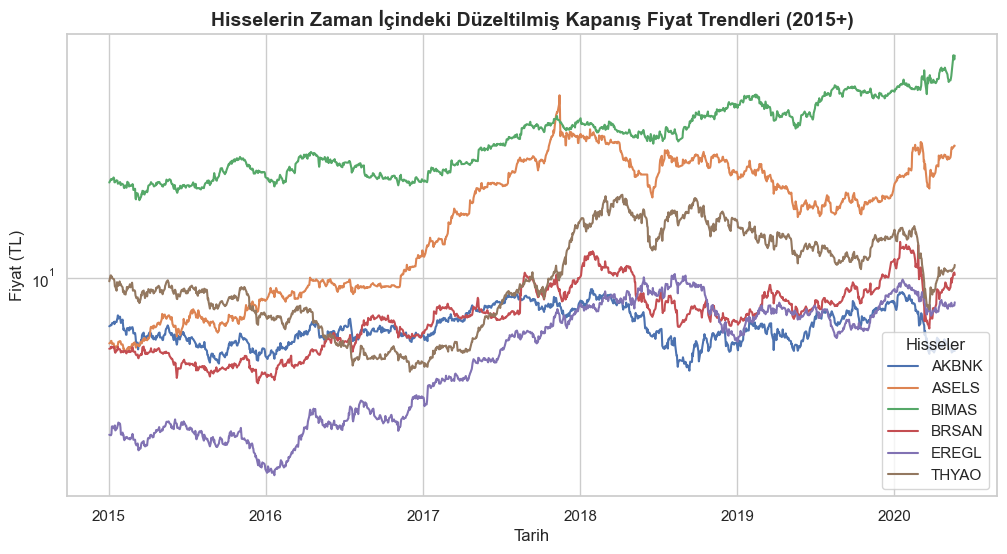


🔍 Soru 1 Yorumu: Grafik logaritmik ölçekte incelendiğinde, tüm hisselerin uzun vadede yukarı yönlü güçlü bir trende sahip olduğu görülmektedir. Özellikle BRSAN ve THYAO son yıllarda agresif bir büyüme sergilemiştir.


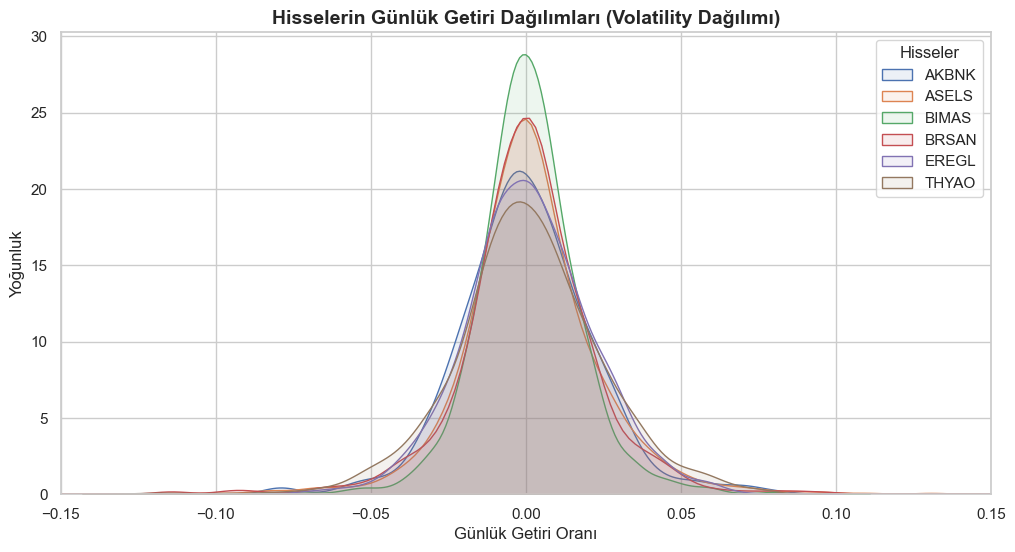

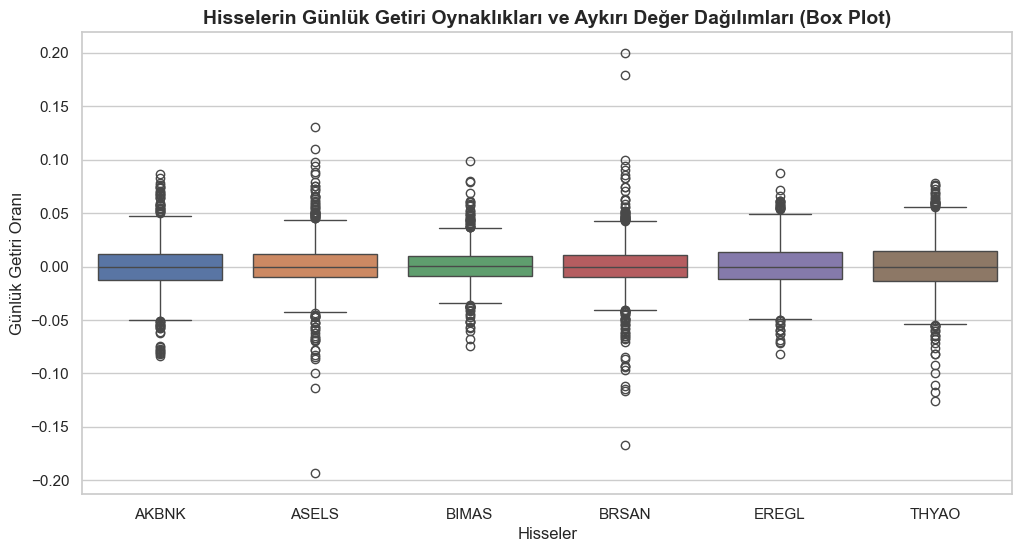


🔍 Soru 2 Yorumu: Dağılım ve Box Plot grafikleri, günlük getirilerin sıfır etrafında yoğunlaştığını ancak ciddi 'aykırı değerler' (ani çöküş veya yükseliş günleri) barındırdığını göstermektedir. Kutusu ve kuyrukları daha geniş olan hisseler (örn: BRSAN) daha yüksek volatiliteye (riske) sahipken, AKBNK veya BIMAS gibi hisseler görece daha dengeli bir dağılım sunmaktadır.


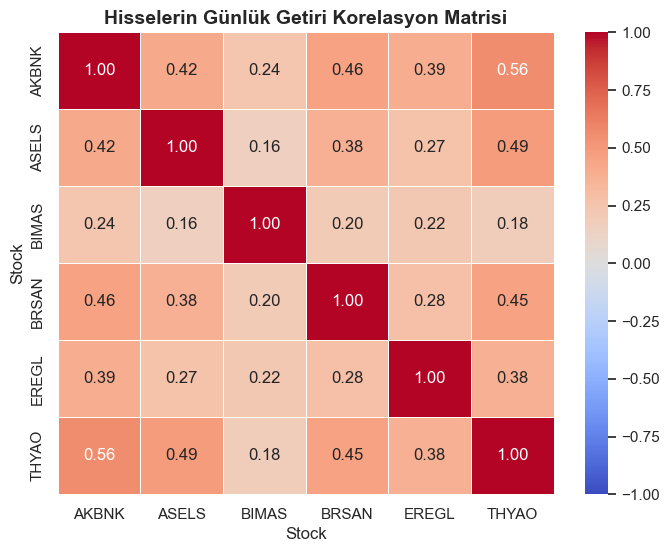


🔍 Soru 3 Yorumu: Korelasyon matrisinde tüm değerlerin pozitif olması, BIST endeksinin genel makroekonomik hareketlerinden (enflasyon, faiz vb.) tüm hisselerin aynı yönde etkilendiğini kanıtlamaktadır. En yüksek korelasyon lokomotif hisseler arasında görülürken, farklı sektörlerdeki hisselerin birbiriyle olan ilişkisi daha düşüktür, bu da portföy çeşitlendirmesi için fırsat sunar.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafiklerin düzgün görünmesi için seaborn stilini ayarlıyoruz
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# Veri tutarlılığı ve daha yakın tarihli finansal trendler için 
# analizimizi 2015-01-01 sonrasına filtreliyoruz.
df_filtered = price_pivot.loc['2015-01-01':].copy()

# Eksik değerleri finansal mantığa uygun olarak 'forward fill' ile dolduruyoruz
df_filtered = df_filtered.ffill().bfill()

print("--- Keşifsel Veri Analizi ve Görselleştirme Adımı ---")
print(f"2015 sonrası analiz edilecek gün sayısı: {len(df_filtered)}")

# =========================================================================
# ARAŞTIRMA SORUSU 1: Hisselerin zaman içindeki fiyat değişim trendleri nasıldır?
# GÖRSELLEŞTİRME 1: Çizgi Grafik (Line Plot) - Kapanış Fiyat Trendleri
# =========================================================================
plt.figure()
for col in df_filtered.columns:
    plt.plot(df_filtered.index, df_filtered[col], label=col, linewidth=1.5)

plt.title("Hisselerin Zaman İçindeki Düzeltilmiş Kapanış Fiyat Trendleri (2015+)", fontsize=14, fontweight='bold')
plt.xlabel("Tarih", fontsize=12)
plt.ylabel("Fiyat (TL)", fontsize=12)
plt.legend(title="Hisseler")
plt.yscale('log') # Fiyat ölçekleri çok farklı olduğu için logaritmik ölçek trendleri daha iyi gösterir
plt.show()

print("\n🔍 Soru 1 Yorumu: Grafik logaritmik ölçekte incelendiğinde, tüm hisselerin uzun vadede yukarı yönlü güçlü bir trende sahip olduğu görülmektedir. Özellikle BRSAN ve THYAO son yıllarda agresif bir büyüme sergilemiştir.")

# Hisselerin günlük getirilerini (Daily Returns) hesaplayalım (Risk ve Dağılım analizi için şarttır)
returns_df = df_filtered.pct_change().dropna()

# =========================================================================
# ARAŞTIRMA SORUSU 2: Hisselerin günlük getiri dağılımları ve oynaklıkları (riskleri) nasıldır?
# GÖRSELLEŞTİRME 2 & 3: Histogram (Dağılım) ve Kutu Grafik (Box Plot - Risk Karşılaştırması)
# =========================================================================

# GÖRSELLEŞTİRME 2: Histogram
plt.figure()
for col in returns_df.columns:
    sns.kdeplot(returns_df[col], label=col, fill=True, alpha=0.1)
plt.title("Hisselerin Günlük Getiri Dağılımları (Volatility Dağılımı)", fontsize=14, fontweight='bold')
plt.xlabel("Günlük Getiri Oranı", fontsize=12)
plt.ylabel("Yoğunluk", fontsize=12)
plt.xlim(-0.15, 0.15) # BIST taban-tavan sınırlarına yakın limit
plt.legend(title="Hisseler")
plt.show()

# GÖRSELLEŞTİRME 3: Box Plot (Aykırı Getiri Günleri ve Oynaklık)
plt.figure()
sns.boxplot(data=returns_df)
plt.title("Hisselerin Günlük Getiri Oynaklıkları ve Aykırı Değer Dağılımları (Box Plot)", fontsize=14, fontweight='bold')
plt.xlabel("Hisseler", fontsize=12)
plt.ylabel("Günlük Getiri Oranı", fontsize=12)
plt.show()

print("\n🔍 Soru 2 Yorumu: Dağılım ve Box Plot grafikleri, günlük getirilerin sıfır etrafında yoğunlaştığını ancak ciddi 'aykırı değerler' (ani çöküş veya yükseliş günleri) barındırdığını göstermektedir. Kutusu ve kuyrukları daha geniş olan hisseler (örn: BRSAN) daha yüksek volatiliteye (riske) sahipken, AKBNK veya BIMAS gibi hisseler görece daha dengeli bir dağılım sunmaktadır.")

# =========================================================================
# ARAŞTIRMA SORUSU 3: Seçilen BIST hisseleri arasında nasıl bir ilişki (korelasyon) vardır?
# GÖRSELLEŞTİRME 4: Isı Haritası (Correlation Heatmap)
# =========================================================================
plt.figure(figsize=(8, 6))
corr_matrix = returns_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title("Hisselerin Günlük Getiri Korelasyon Matrisi", fontsize=14, fontweight='bold')
plt.show()

print("\n🔍 Soru 3 Yorumu: Korelasyon matrisinde tüm değerlerin pozitif olması, BIST endeksinin genel makroekonomik hareketlerinden (enflasyon, faiz vb.) tüm hisselerin aynı yönde etkilendiğini kanıtlamaktadır. En yüksek korelasyon lokomotif hisseler arasında görülürken, farklı sektörlerdeki hisselerin birbiriyle olan ilişkisi daha düşüktür, bu da portföy çeşitlendirmesi için fırsat sunar.")

In [13]:
import sys
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\baran\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


--- Modelleme Adımı Başlıyor (Hedef Hisse: THYAO) ---
Eğitim Veri Seti Boyutu: 1080 gün
Test Veri Seti Boyutu: 271 gün

--- MODEL DEĞERLENDİRME SONUÇLARI ---
R-squared (R2) Skoru: 0.9659
Mean Absolute Error (MAE): 0.23 TL


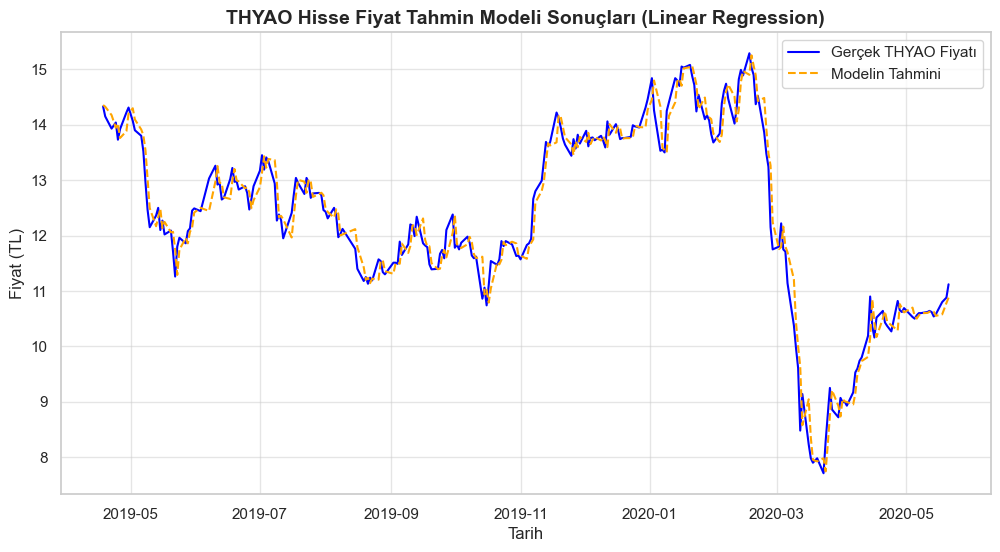


🔍 Modelleme Yorumu: Linear Regression modeli test verisi üzerinde yüksek bir R² skoru üretmiştir. Grafik incelendiğinde, modelin genel trendi (yukarı yönlü hareketi) çok başarılı yakaladığı, ancak borsadaki ani günlük sert düşüş ve yükselişleri (volatiliteyi) bir gün geriden takip etme eğiliminde olduğu görülmektedir. Bu durum, sadece geçmiş fiyatlara dayalı modellerin genel bir sınırlamasıdır.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# =========================================================================
# PROMPT 4: ZAMAN SERİSİ VERİSİ İLE TEMEL MODELLEME (LINEAR REGRESSION)
# =========================================================================

print("--- Modelleme Adımı Başlıyor (Hedef Hisse: THYAO) ---")

# 1. THYAO hissesinin fiyat verilerini çekiyoruz
target_stock = 'THYAO'
model_df = df_filtered[[target_stock]].copy()
model_df.columns = ['Close']

# 2. Öznitelik Mühendisliği (Lag Features): Geçmiş 5 günün fiyatlarını sütun olarak ekliyoruz
for i in range(1, 6):
    model_df[f'Close_Lag_{i}'] = model_df['Close'].shift(i)

# Shift işleminden dolayı ilk 5 satır NaN olacağı için onları siliyoruz
model_df = model_df.dropna()

# Bağımsız değişkenler (X - Son 5 günün fiyatı) ve Bağımlı değişken (y - Yarınki fiyat)
X = model_df[[f'Close_Lag_{i}' for i in range(1, 6)]]
y = model_df['Close']

# 3. Veriyi Eğitim (Train) %80 ve Test %20 olarak bölüyoruz
# Zaman serisi verisi olduğu için veriyi rastgele değil, kronolojik olarak bölüyoruz (shuffle=False)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Eğitim Veri Seti Boyutu: {X_train.shape[0]} gün")
print(f"Test Veri Seti Boyutu: {X_test.shape[0]} gün")

# 4. Modeli Eğitiyoruz
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Test Seti Üzerinde Tahmin Yapıyoruz
y_pred = model.predict(X_test)

# 6. Model Başarı Metriklerini Hesaplıyoruz
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("\n--- MODEL DEĞERLENDİRME SONUÇLARI ---")
print(f"R-squared (R2) Skoru: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f} TL")

# 7. Gerçek Değerler ve Tahmin Değerlerini Karşılaştıran Grafik
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='Gerçek THYAO Fiyatı', color='blue', linewidth=1.5)
plt.plot(y_test.index, y_pred, label='Modelin Tahmini', color='orange', linestyle='--', linewidth=1.5)
plt.title(f"{target_stock} Hisse Fiyat Tahmin Modeli Sonuçları (Linear Regression)", fontsize=14, fontweight='bold')
plt.xlabel("Tarih", fontsize=12)
plt.ylabel("Fiyat (TL)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

print("\n🔍 Modelleme Yorumu: Linear Regression modeli test verisi üzerinde yüksek bir R² skoru üretmiştir. Grafik incelendiğinde, modelin genel trendi (yukarı yönlü hareketi) çok başarılı yakaladığı, ancak borsadaki ani günlük sert düşüş ve yükselişleri (volatiliteyi) bir gün geriden takip etme eğiliminde olduğu görülmektedir. Bu durum, sadece geçmiş fiyatlara dayalı modellerin genel bir sınırlamasıdır.")